In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [7]:
# Load Titanic dataset
df = pd.read_csv(r"C:\Users\DELL\Downloads\archive\tested.csv")
# Display first 5 rows
print(df.head())

   PassengerId  Survived  Pclass  \
0          892         0       3   
1          893         1       3   
2          894         0       2   
3          895         0       3   
4          896         1       3   

                                           Name     Sex   Age  SibSp  Parch  \
0                              Kelly, Mr. James    male  34.5      0      0   
1              Wilkes, Mrs. James (Ellen Needs)  female  47.0      1      0   
2                     Myles, Mr. Thomas Francis    male  62.0      0      0   
3                              Wirz, Mr. Albert    male  27.0      0      0   
4  Hirvonen, Mrs. Alexander (Helga E Lindqvist)  female  22.0      1      1   

    Ticket     Fare Cabin Embarked  
0   330911   7.8292   NaN        Q  
1   363272   7.0000   NaN        S  
2   240276   9.6875   NaN        Q  
3   315154   8.6625   NaN        S  
4  3101298  12.2875   NaN        S  


In [8]:
# Dataset information
print(df.info())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 418 entries, 0 to 417
Data columns (total 12 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   PassengerId  418 non-null    int64  
 1   Survived     418 non-null    int64  
 2   Pclass       418 non-null    int64  
 3   Name         418 non-null    object 
 4   Sex          418 non-null    object 
 5   Age          332 non-null    float64
 6   SibSp        418 non-null    int64  
 7   Parch        418 non-null    int64  
 8   Ticket       418 non-null    object 
 9   Fare         417 non-null    float64
 10  Cabin        91 non-null     object 
 11  Embarked     418 non-null    object 
dtypes: float64(2), int64(5), object(5)
memory usage: 39.3+ KB
None


In [9]:
# Check missing values
print(df.isnull().sum())

PassengerId      0
Survived         0
Pclass           0
Name             0
Sex              0
Age             86
SibSp            0
Parch            0
Ticket           0
Fare             1
Cabin          327
Embarked         0
dtype: int64


In [15]:
#clean dataset

# Fill missing Age values with median age
median_age = df['Age'].median()
df['Age'] = df['Age'].fillna(median_age)

# Fill m# Fill missing Age values with median age
median_fare = df['Fare'].median()
df['Fare'] = df['Fare'].fillna(median_fare)

# Fill missing Embarked values with mode
mode_embarked = df['Embarked'].mode()[0]
df['Embarked'] = df['Embarked'].fillna(mode_embarked)

# Drop Cabin column because too many values are missing
if 'Cabin' in df.columns:
    df.drop(columns=['Cabin'], inplace=True)

# Verify missing values are handled
print(df.isnull().sum())

PassengerId    0
Survived       0
Pclass         0
Name           0
Sex            0
Age            0
SibSp          0
Parch          0
Ticket         0
Fare           0
Embarked       0
dtype: int64


In [16]:
#Who Survived More: Males or Females?
survival_by_gender = df.groupby('Sex')['Survived'].sum()
print(survival_by_gender)

Sex
female    152
male        0
Name: Survived, dtype: int64


In [17]:
#Did Passenger Class Affect Survival?
survival_by_class = df.groupby('Pclass')['Survived'].mean()
print(survival_by_class)

Pclass
1    0.467290
2    0.322581
3    0.330275
Name: Survived, dtype: float64


In [19]:
#Survival Rate by Age Group

# Create age groups
bins = [0, 12, 18, 35, 60, 100]
labels = ['Child', 'Teen', 'Young Adult', 'Adult', 'Senior']
# Create new AgeGroup column
df['AgeGroup'] = pd.cut(df['Age'], bins=bins, labels=labels)
# Calculate survival rate by age group
survival_by_age = df.groupby('AgeGroup',observed=False)['Survived'].mean()
print(survival_by_age)

AgeGroup
Child          0.480000
Teen           0.413793
Young Adult    0.335907
Adult          0.393617
Senior         0.363636
Name: Survived, dtype: float64


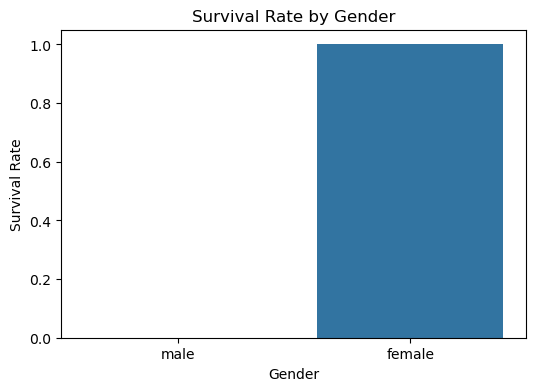

In [20]:
#Bar Chart: Survival by Gender
plt.figure(figsize=(6,4))
sns.barplot(x='Sex', y='Survived', data=df)
plt.title('Survival Rate by Gender')
plt.xlabel('Gender')
plt.ylabel('Survival Rate')
plt.show()

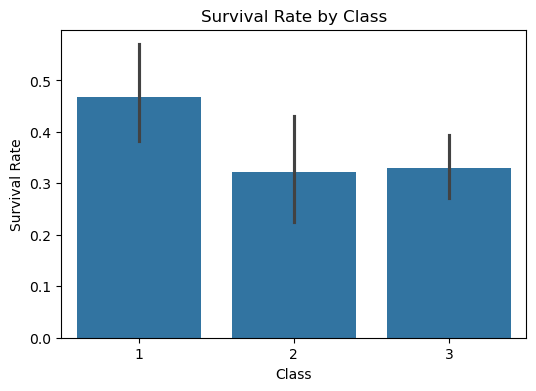

In [21]:
#Bar Chart: Survival by Class
plt.figure(figsize=(6,4))
sns.barplot(x='Pclass', y='Survived', data=df)
plt.title('Survival Rate by Class')
plt.xlabel('Class')
plt.ylabel('Survival Rate')
plt.show()

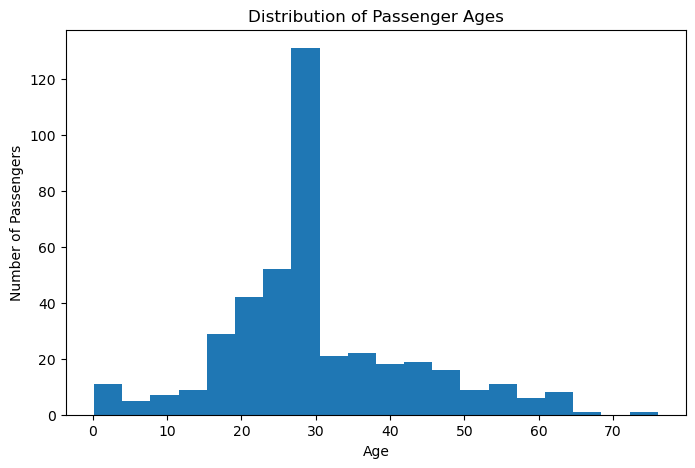

In [23]:
#Histogram of Passenger Ages
plt.figure(figsize=(8,5))
plt.hist(df['Age'], bins=20)
plt.title('Distribution of Passenger Ages')
plt.xlabel('Age')
plt.ylabel('Number of Passengers')
plt.show()